## Load Data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

_notebook_dir = Path.cwd()
if _notebook_dir.name == "notebooks":
    dataset_path = _notebook_dir.parent / "dataset" / "pokemon_cards_dataset_cleaned.csv"
else:
    dataset_path = _notebook_dir / "backend" / "dataset" / "pokemon_cards_dataset_cleaned.csv"

try:
    df = pd.read_csv(dataset_path)
    df.info()
    print("\nData berhasil dimuat!")
except FileNotFoundError:
    print(f"File tidak ditemukan di: {dataset_path}")

<class 'pandas.DataFrame'>
RangeIndex: 20617 entries, 0 to 20616
Data columns (total 22 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   card_id                                           20617 non-null  str    
 1   name                                              20617 non-null  str    
 2   supertype                                         20617 non-null  str    
 3   subtypes                                          20442 non-null  str    
 4   types                                             17426 non-null  str    
 5   hp                                                17459 non-null  float64
 6   number                                            20617 non-null  str    
 7   rarity                                            20361 non-null  str    
 8   artist                                            19340 non-null  str    
 9   set.id                      

## Definisikan Target Harga

In [12]:
# Kandidat target variable
df[["prices.tcgplayer_variants.normal.market", "prices.cardmarket_avg_sell", "effective_market_price"]].describe()

,prices.tcgplayer_variants.normal.market,prices.cardmarket_avg_sell,effective_market_price
count,11540.000000,19081.000000,19686.000000
mean,4.795507,12.835737,22.389274
std,42.140914,141.372677,115.380706
min,0.010000,0.000000,0.010000
25%,0.170000,0.120000,0.250000
50%,0.320000,0.670000,0.960000
75%,1.080000,4.390000,7.427500
max,2500.990000,14999.990000,4500.000000


## UNIFIED ASSOCIATION MATRIX (Opsi B)
### Pearson r       → Numerik vs Numerik
### Eta-squared η²  → Kategorik vs Numerik
### Cramér's V      → Kategorik vs Kategorik

Menghitung association matrix...
Selesai!


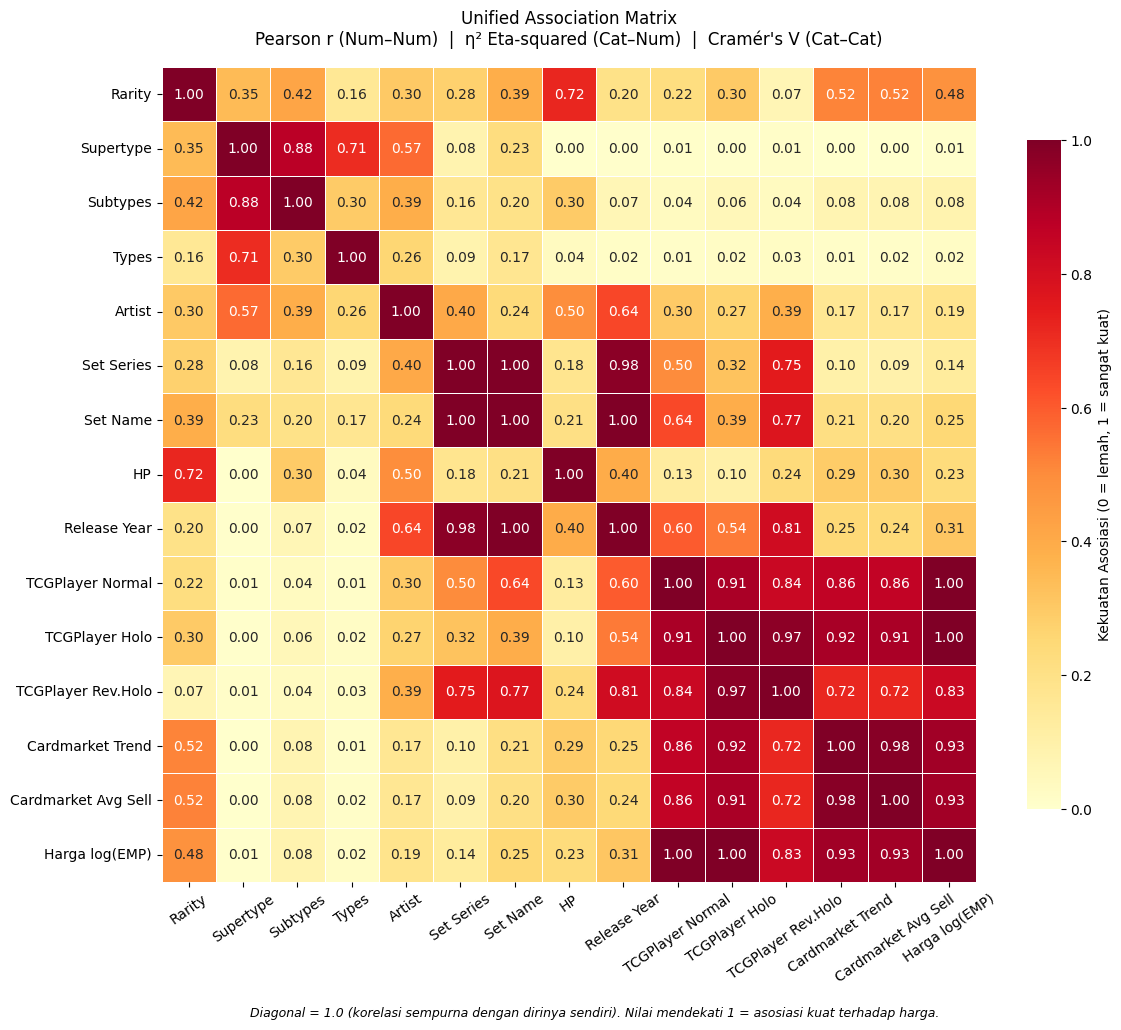


=== Ranking Pengaruh terhadap Harga (log effective_market_price) ===
TCGPlayer Normal  ███████████████████   1.000
TCGPlayer Holo   ███████████████████   0.997
Cardmarket Trend  ██████████████████    0.933
Cardmarket Avg Sell  ██████████████████    0.927
TCGPlayer Rev.Holo  ████████████████      0.830
Rarity           █████████             0.483
Release Year     ██████                0.311
Set Name         █████                 0.251
HP               ████                  0.234
Artist           ███                   0.186
Set Series       ██                    0.136
Subtypes         █                     0.085
Types                                  0.020
Supertype                              0.007


In [16]:
# --- 1. Siapkan kolom ---

# Flatten subtypes & types (ambil elemen pertama kalau ada koma)
df["subtypes_clean"] = df["subtypes"].apply(
    lambda x: str(x).split(",")[0].strip() if pd.notna(x) else "Unknown"
)
df["types_clean"] = df["types"].apply(
    lambda x: str(x).split(",")[0].strip() if pd.notna(x) else "Unknown"
)

# Konversi kolom numerik dasar
df["hp"]                     = pd.to_numeric(df["hp"], errors="coerce")
df["release_year"]           = pd.to_numeric(df["release_year"], errors="coerce")
df["effective_market_price"] = pd.to_numeric(df["effective_market_price"], errors="coerce")

# Konversi kolom harga tambahan
price_cols_extra = [
    "prices.tcgplayer_variants.normal.market",
    "prices.tcgplayer_variants.holofoil.market",
    "prices.tcgplayer_variants.reverseHolofoil.market",
    "prices.cardmarket_trend",
    "prices.cardmarket_avg_sell",
]
for col in price_cols_extra:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Log transform semua kolom harga
df["log_price"]               = np.log1p(df["effective_market_price"])
df["log_tcgplayer_normal"]    = np.log1p(df["prices.tcgplayer_variants.normal.market"])
df["log_tcgplayer_holo"]      = np.log1p(df["prices.tcgplayer_variants.holofoil.market"])
df["log_tcgplayer_revholo"]   = np.log1p(df["prices.tcgplayer_variants.reverseHolofoil.market"])
df["log_cardmarket_trend"]    = np.log1p(df["prices.cardmarket_trend"])
df["log_cardmarket_avgsell"]  = np.log1p(df["prices.cardmarket_avg_sell"])

# Definisi field yang dianalisis
categ_cols = [
    "rarity",
    "supertype",
    "subtypes_clean",
    "types_clean",
    "artist",
    "set.series",
    "set.name",
]

numeric_cols = [
    "hp",
    "release_year",
    "log_tcgplayer_normal",
    "log_tcgplayer_holo",
    "log_tcgplayer_revholo",
    "log_cardmarket_trend",
    "log_cardmarket_avgsell",
    "log_price",              # EMP — target utama
]

all_fields = categ_cols + numeric_cols

# Label bersih untuk tampilan
label_map = {
    "rarity":                   "Rarity",
    "supertype":                "Supertype",
    "subtypes_clean":           "Subtypes",
    "types_clean":              "Types",
    "artist":                   "Artist",
    "set.series":               "Set Series",
    "set.name":                 "Set Name",
    "hp":                       "HP",
    "release_year":             "Release Year",
    "log_tcgplayer_normal":     "TCGPlayer Normal",
    "log_tcgplayer_holo":       "TCGPlayer Holo",
    "log_tcgplayer_revholo":    "TCGPlayer Rev.Holo",
    "log_cardmarket_trend":     "Cardmarket Trend",
    "log_cardmarket_avgsell":   "Cardmarket Avg Sell",
    "log_price":                "Harga log(EMP)",
}

# --- 2. Helper functions ---

def cramers_v(x, y):
    """Kategorik vs Kategorik"""
    ct = pd.crosstab(x.fillna("?"), y.fillna("?"))
    chi2 = stats.chi2_contingency(ct, correction=False)[0]
    n = ct.sum().sum()
    k = min(ct.shape) - 1
    return np.sqrt(chi2 / (n * k)) if (n * k) > 0 else 0.0

def eta_squared(cat, num):
    """Kategorik vs Numerik"""
    cat = cat.fillna("?")
    num = pd.to_numeric(num, errors="coerce")
    mask = num.notna()
    cat, num = cat[mask], num[mask]
    if len(num) < 3:
        return 0.0
    grand_mean = num.mean()
    groups = [num[cat == c] for c in cat.unique()]
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups if len(g) > 0)
    ss_total   = ((num - grand_mean)**2).sum()
    return ss_between / ss_total if ss_total > 0 else 0.0

def pearson_abs(x, y):
    """Numerik vs Numerik"""
    mask = x.notna() & y.notna()
    if mask.sum() < 3:
        return 0.0
    r, _ = stats.pearsonr(x[mask], y[mask])
    return abs(r)

# --- 3. Bangun matrix ---

n = len(all_fields)
matrix = pd.DataFrame(
    np.zeros((n, n)),
    index=all_fields,
    columns=all_fields
)

print("Menghitung association matrix...")
for i, col_a in enumerate(all_fields):
    for j, col_b in enumerate(all_fields):
        if i == j:
            matrix.loc[col_a, col_b] = 1.0
        elif col_a in categ_cols and col_b in categ_cols:
            matrix.loc[col_a, col_b] = cramers_v(df[col_a], df[col_b])
        elif col_a in categ_cols and col_b in numeric_cols:
            matrix.loc[col_a, col_b] = eta_squared(df[col_a], df[col_b])
        elif col_a in numeric_cols and col_b in categ_cols:
            matrix.loc[col_a, col_b] = eta_squared(df[col_b], df[col_a])
        else:
            matrix.loc[col_a, col_b] = pearson_abs(df[col_a], df[col_b])

# Rename index & kolom ke label bersih
matrix.index   = [label_map[f] for f in all_fields]
matrix.columns = [label_map[f] for f in all_fields]

print("Selesai!")

# --- 4. Plot ---

# Annotation: bold untuk nilai >= 0.3
annot = matrix.copy().round(2).astype(str)
for r in matrix.index:
    for c in matrix.columns:
        val = matrix.loc[r, c]
        annot.loc[r, c] = f"{val:.2f}"

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    matrix,
    ax=ax,
    annot=annot,
    fmt="",
    cmap="YlOrRd",
    square=True,
    linewidths=0.5,
    vmin=0, vmax=1,
    cbar_kws={"label": "Kekuatan Asosiasi (0 = lemah, 1 = sangat kuat)", "shrink": 0.8}
)

ax.set_title(
    "Unified Association Matrix\n"
    "Pearson r (Num–Num)  |  η² Eta-squared (Cat–Num)  |  Cramér's V (Cat–Cat)",
    pad=16, fontsize=12
)
ax.tick_params(axis="x", rotation=35)
ax.tick_params(axis="y", rotation=0)

fig.text(
    0.5, -0.02,
    "Diagonal = 1.0 (korelasi sempurna dengan dirinya sendiri). "
    "Nilai mendekati 1 = asosiasi kuat terhadap harga.",
    ha="center", fontsize=9, style="italic"
)

plt.tight_layout()
plt.show()

# --- 5. Print ranking pengaruh terhadap harga ---
print("\n=== Ranking Pengaruh terhadap Harga (log effective_market_price) ===")
harga_row = matrix.loc["Harga log(EMP)"].drop("Harga log(EMP)").sort_values(ascending=False)
for field, val in harga_row.items():
    bar = "█" * int(val * 20)
    print(f"{field:15s}  {bar:<20s}  {val:.3f}")

## Drill Down -- Rarity vs Harga

In [18]:
rarity_stats = (
    df.dropna(subset=["rarity", "effective_market_price"])
    .groupby("rarity")["effective_market_price"]
    .agg(
        median_harga="median",
        rata_rata="mean",
        jumlah_kartu="count",
    )
    .sort_values(by="median_harga", ascending=False)
)
print(rarity_stats)

                           median_harga    rata_rata  jumlah_kartu
rarity                                                            
Rare Holo Star                 1333.560  1472.113600            25
Black White Rare                554.760   554.760000             2
Mega Hyper Rare                 247.840   231.660000             3
LEGEND                          230.000   263.654444            18
Rare Shining                    207.430   291.164375            16
Rare Holo LV.X                  100.490   151.653750            56
Rare Prime                       76.480   152.157308            26
Rare Holo EX                     33.390   124.380881           318
Special Illustration Rare        29.590    78.317747           182
Rare Shiny GX                    26.350    76.620857            35
Rare Ultra                       18.070    70.831404           798
Rare Rainbow                     17.130    62.364043           324
Rare Secret                      15.360   127.396800          

C:\Users\Tigro\AppData\Local\Temp\ipykernel_11992\2282441411.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


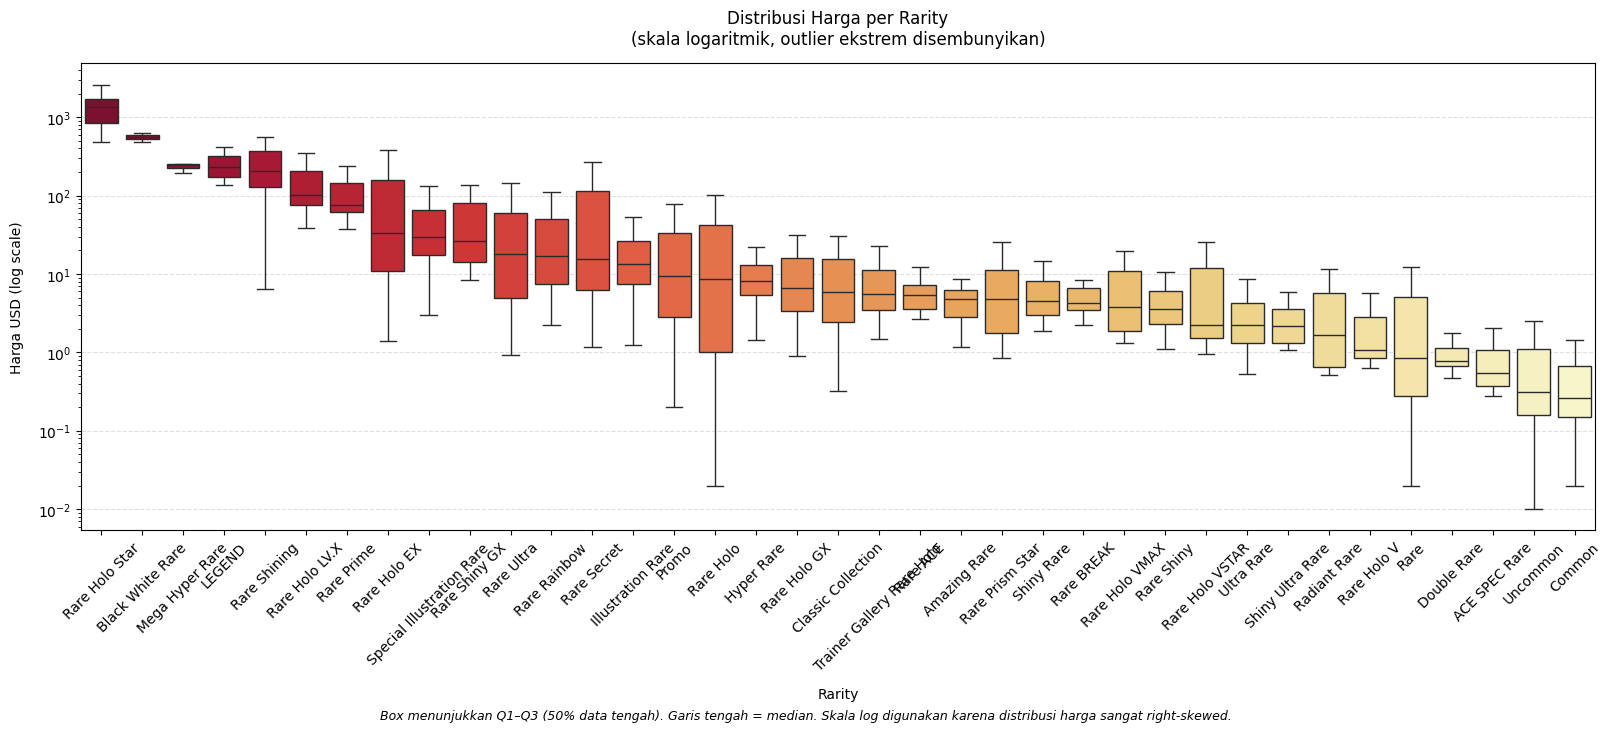

In [8]:
# ── Akademik: Box Plot distribusi harga per rarity ──────────────────
order_rarity = (
    df.dropna(subset=["rarity", "effective_market_price"])
    .groupby("rarity")["effective_market_price"]
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(16, 7), constrained_layout=True)

sns.boxplot(
    data=df.dropna(subset=["rarity", "effective_market_price"]),
    x="rarity", y="effective_market_price",
    order=order_rarity,
    showfliers=False,   # sembunyikan outlier ekstrem
    palette="YlOrRd_r",
    ax=ax
)

ax.set_yscale("log")
ax.set_title("Distribusi Harga per Rarity\n(skala logaritmik, outlier ekstrem disembunyikan)", pad=14)
ax.set_xlabel("Rarity", labelpad=10)
ax.set_ylabel("Harga USD (log scale)", labelpad=10)
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", linestyle="--", alpha=0.4)

fig.text(
    0.5, -0.02,
    "Box menunjukkan Q1–Q3 (50% data tengah). Garis tengah = median. "
    "Skala log digunakan karena distribusi harga sangat right-skewed.",
    ha="center", fontsize=9, style="italic"
)
plt.show()

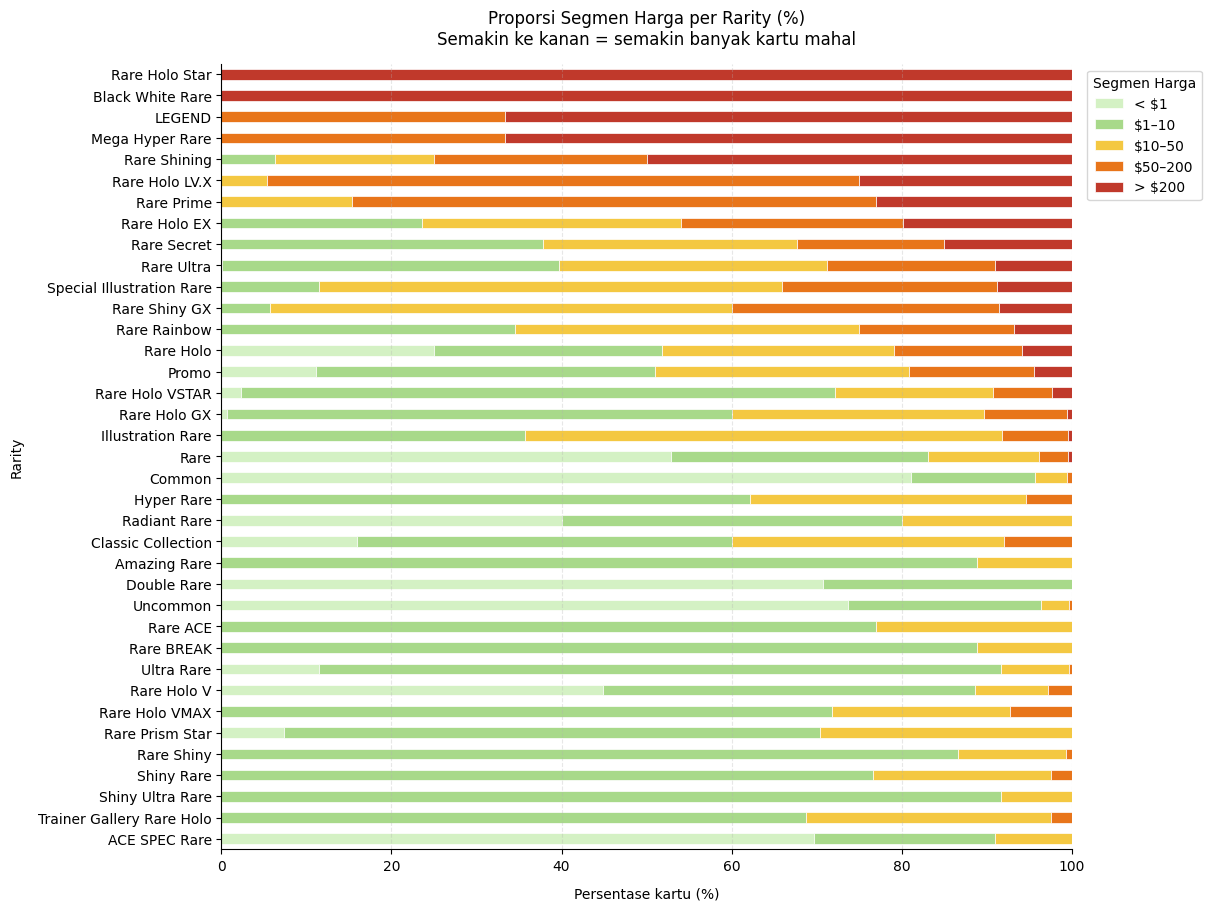

In [9]:
# ── Dashboard: Proporsi segmen harga per rarity ──────────────────────
bins   = [0, 1, 10, 50, 200, float("inf")]
labels = ["< $1", "$1–10", "$10–50", "$50–200", "> $200"]

df["price_segment"] = pd.cut(
    df["effective_market_price"],
    bins=bins, labels=labels
)

segment_pct = (
    df.dropna(subset=["rarity", "price_segment"])
    .groupby(["rarity", "price_segment"], observed=True)
    .size()
    .unstack(fill_value=0)
    .apply(lambda x: x / x.sum() * 100, axis=1)
)

# Urutkan berdasarkan proporsi kartu paling mahal
segment_pct = segment_pct.loc[
    segment_pct["> $200"].sort_values(ascending=True).index
]

colors = ["#d4f1c4", "#a8d98a", "#f4c842", "#e8751a", "#c0392b"]

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)
segment_pct.plot(kind="barh", stacked=True, ax=ax, color=colors, edgecolor="white", linewidth=0.5)

ax.set_title("Proporsi Segmen Harga per Rarity (%)\nSemakin ke kanan = semakin banyak kartu mahal", pad=14)
ax.set_xlabel("Persentase kartu (%)", labelpad=10)
ax.set_ylabel("Rarity", labelpad=10)
ax.legend(title="Segmen Harga", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.show()

## Drill Down -- Realese Year vs Harga

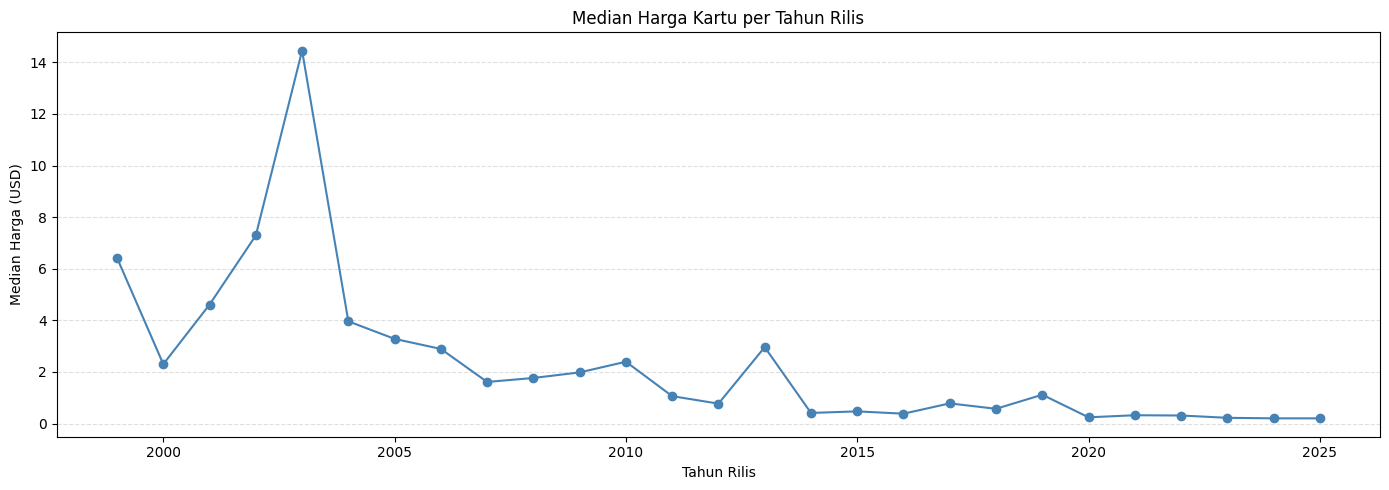

In [6]:
year_trend = (
    df.dropna(subset=["release_year", "effective_market_price"])
    .groupby("release_year")["effective_market_price"]
    .median()
    .reset_index()
)

plt.figure(figsize=(14, 5))
plt.plot(year_trend["release_year"], year_trend["effective_market_price"], 
         marker="o", color="steelblue")
plt.title("Median Harga Kartu per Tahun Rilis")
plt.xlabel("Tahun Rilis")
plt.ylabel("Median Harga (USD)")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

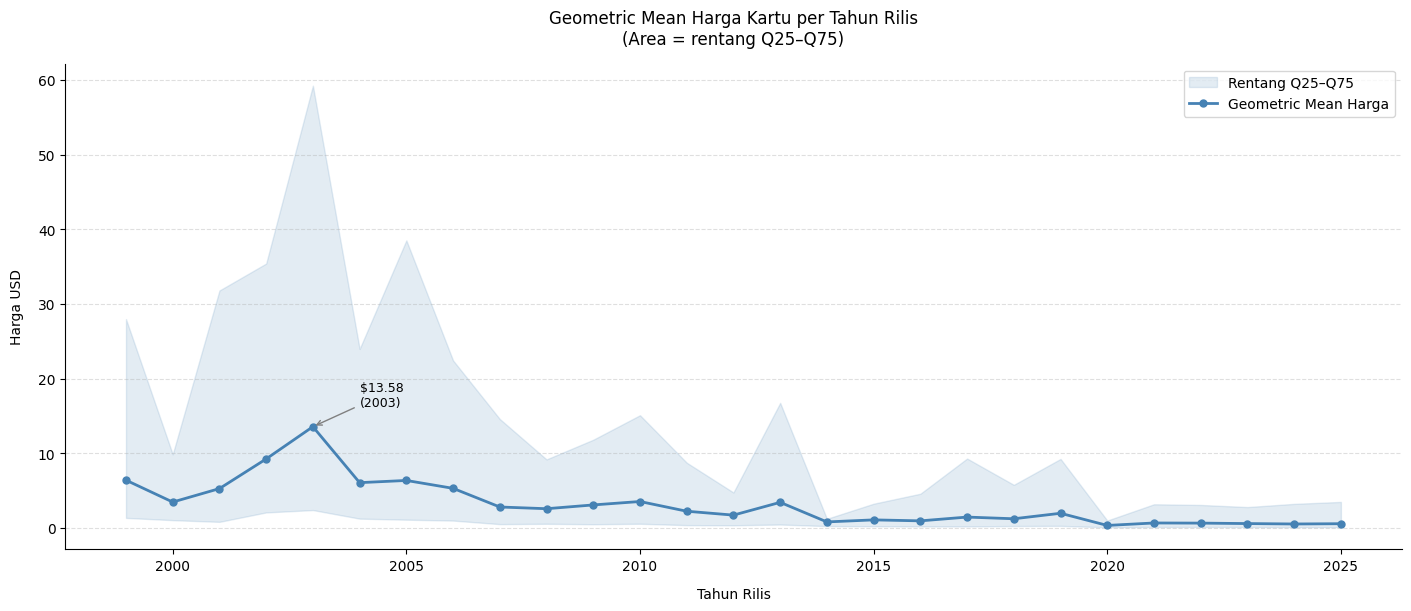

In [10]:
# ── Akademik: Geometric Mean harga per tahun rilis ───────────────────
year_geo = (
    df.dropna(subset=["release_year", "effective_market_price"])
    .query("effective_market_price > 0")
    .groupby("release_year")["effective_market_price"]
    .agg(
        geo_mean=lambda x: np.exp(np.log(x).mean()),
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        count="count"
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6), constrained_layout=True)

# Confidence band Q25–Q75
ax.fill_between(
    year_geo["release_year"],
    year_geo["q25"], year_geo["q75"],
    alpha=0.15, color="steelblue", label="Rentang Q25–Q75"
)

# Geometric mean line
ax.plot(
    year_geo["release_year"], year_geo["geo_mean"],
    marker="o", color="steelblue", linewidth=2, markersize=5,
    label="Geometric Mean Harga"
)

ax.set_title("Geometric Mean Harga Kartu per Tahun Rilis\n(Area = rentang Q25–Q75)", pad=14)
ax.set_xlabel("Tahun Rilis", labelpad=10)
ax.set_ylabel("Harga USD", labelpad=10)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

# Annotasi kartu terbanyak
peak = year_geo.loc[year_geo["geo_mean"].idxmax()]
ax.annotate(
    f"${peak['geo_mean']:.2f}\n({int(peak['release_year'])})",
    xy=(peak["release_year"], peak["geo_mean"]),
    xytext=(peak["release_year"] + 1, peak["geo_mean"] * 1.2),
    arrowprops=dict(arrowstyle="->", color="gray"),
    fontsize=9
)

plt.show()

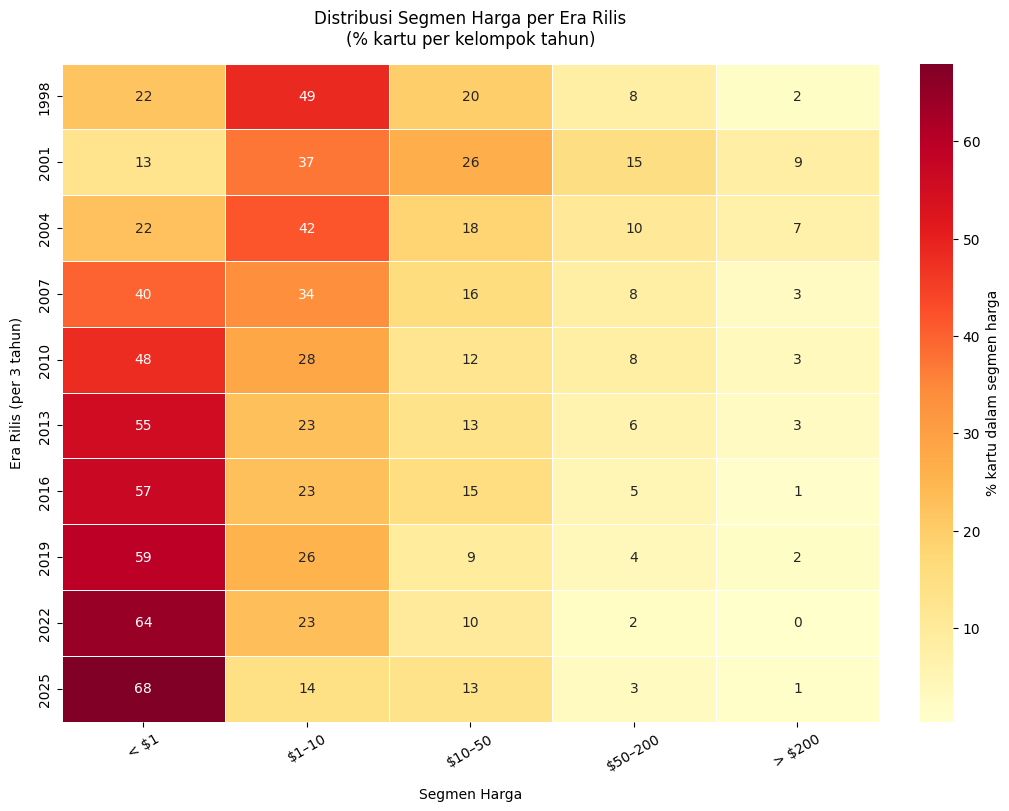

In [11]:
# ── Dashboard: Heatmap Tahun Rilis × Segmen Harga ────────────────────
# Kelompokkan tahun per 3 tahun agar tidak terlalu granular
df["year_group"] = (df["release_year"] // 3 * 3).astype("Int64").astype(str)

year_segment = (
    df.dropna(subset=["year_group", "price_segment"])
    .groupby(["year_group", "price_segment"], observed=True)
    .size()
    .unstack(fill_value=0)
    .apply(lambda x: x / x.sum() * 100, axis=1)  # persen
)

fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)

sns.heatmap(
    year_segment,
    annot=True, fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "% kartu dalam segmen harga"}
)

ax.set_title("Distribusi Segmen Harga per Era Rilis\n(% kartu per kelompok tahun)", pad=14)
ax.set_xlabel("Segmen Harga", labelpad=10)
ax.set_ylabel("Era Rilis (per 3 tahun)", labelpad=10)
ax.tick_params(axis="x", rotation=30)

plt.show()

## Drill Down -- Artist vs Harga

In [7]:
artist_stats = (
    df.dropna(subset=["artist", "effective_market_price"])
    .groupby("artist")["effective_market_price"]
    .agg(median_harga="median", jumlah_kartu="count")
    .query("jumlah_kartu >= 20")   # filter artist yang cukup sampel
    .sort_values("median_harga", ascending=False)
    .head(15)
)
print(artist_stats)

                   median_harga  jumlah_kartu
artist                                       
Hikaru Koike            148.490            47
Kimiya Masago           108.230            25
Shizurow                 60.700            80
Keiko Fukuyama           50.415            20
ConceptLab               27.150            20
Nakaoka                  18.000            45
Noriko Hotta             16.010            21
Hideaki Hakozaki         12.880            36
Hironobu Yoshida         11.285            38
Shin-ichi Yoshida        10.665            52
Ryo Ueda                  8.065           462
Masako Yamashita          7.740            23
Toshinao Aoki             7.330            59
Jiro Sasumo               6.980            25
Wataru Kawahara           6.005            36


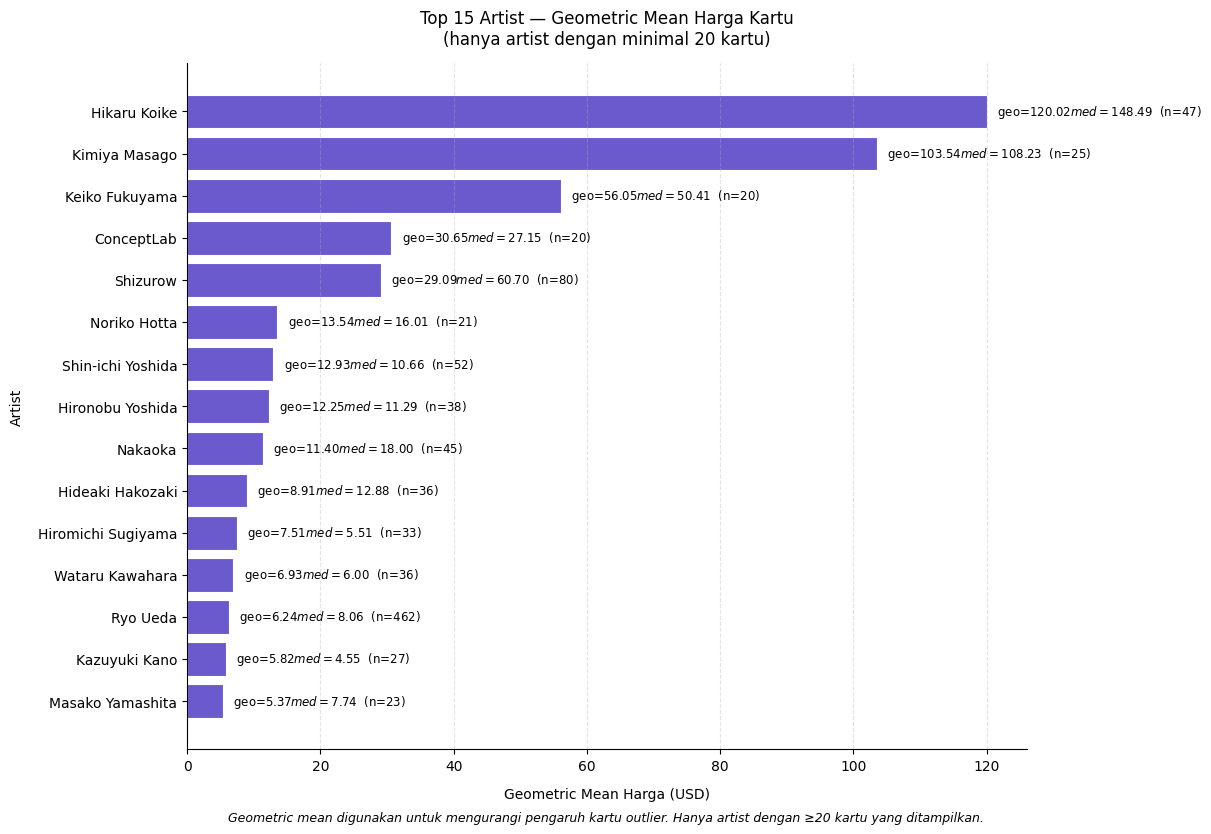

In [12]:
# ── Akademik: Geometric Mean per artist + jumlah kartu ───────────────
MIN_SAMPLE = 20

artist_geo = (
    df.dropna(subset=["artist", "effective_market_price"])
    .query("effective_market_price > 0")
    .groupby("artist")["effective_market_price"]
    .agg(
        geo_mean=lambda x: np.exp(np.log(x).mean()),
        median_price="median",
        count="count"
    )
    .query(f"count >= {MIN_SAMPLE}")
    .sort_values("geo_mean", ascending=True)
    .tail(15)
)

fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)

bars = ax.barh(
    artist_geo.index,
    artist_geo["geo_mean"],
    color="#6a5acd", edgecolor="white", linewidth=0.8
)

for bar, geo, med, cnt in zip(
    bars,
    artist_geo["geo_mean"],
    artist_geo["median_price"],
    artist_geo["count"]
):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"  geo=${geo:.2f}  med=${med:.2f}  (n={cnt})",
        va="center", ha="left", fontsize=8.5
    )

ax.set_title("Top 15 Artist — Geometric Mean Harga Kartu\n(hanya artist dengan minimal 20 kartu)", pad=14)
ax.set_xlabel("Geometric Mean Harga (USD)", labelpad=10)
ax.set_ylabel("Artist", labelpad=10)
ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.spines[["top", "right"]].set_visible(False)

fig.text(
    0.5, -0.02,
    f"Geometric mean digunakan untuk mengurangi pengaruh kartu outlier. "
    f"Hanya artist dengan ≥{MIN_SAMPLE} kartu yang ditampilkan.",
    ha="center", fontsize=9, style="italic"
)

plt.show()

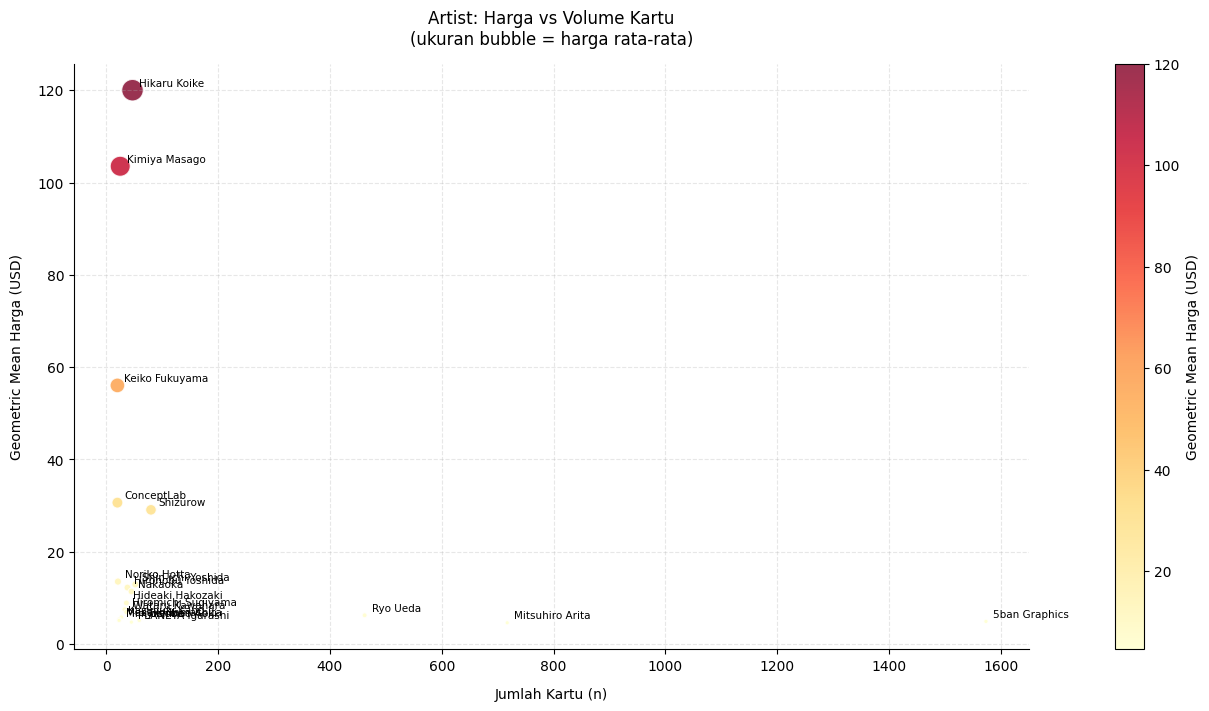

In [13]:
# ── Dashboard: Bubble chart artist — harga vs volume ─────────────────
artist_bubble = (
    df.dropna(subset=["artist", "effective_market_price"])
    .query("effective_market_price > 0")
    .groupby("artist")["effective_market_price"]
    .agg(
        geo_mean=lambda x: np.exp(np.log(x).mean()),
        count="count"
    )
    .query(f"count >= {MIN_SAMPLE}")
    .sort_values("geo_mean", ascending=False)
    .head(20)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

scatter = ax.scatter(
    artist_bubble["count"],
    artist_bubble["geo_mean"],
    s=artist_bubble["geo_mean"] * 2,   # ukuran bubble = harga
    c=artist_bubble["geo_mean"],
    cmap="YlOrRd", alpha=0.8, edgecolors="white", linewidth=0.8
)

# Label nama artist
for _, row in artist_bubble.iterrows():
    ax.annotate(
        row["artist"],
        xy=(row["count"], row["geo_mean"]),
        xytext=(5, 3), textcoords="offset points",
        fontsize=7.5
    )

plt.colorbar(scatter, ax=ax, label="Geometric Mean Harga (USD)")
ax.set_title("Artist: Harga vs Volume Kartu\n(ukuran bubble = harga rata-rata)", pad=14)
ax.set_xlabel("Jumlah Kartu (n)", labelpad=10)
ax.set_ylabel("Geometric Mean Harga (USD)", labelpad=10)
ax.grid(linestyle="--", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.show()

## Drill Down -- HP Sebagai Proxy Rarity

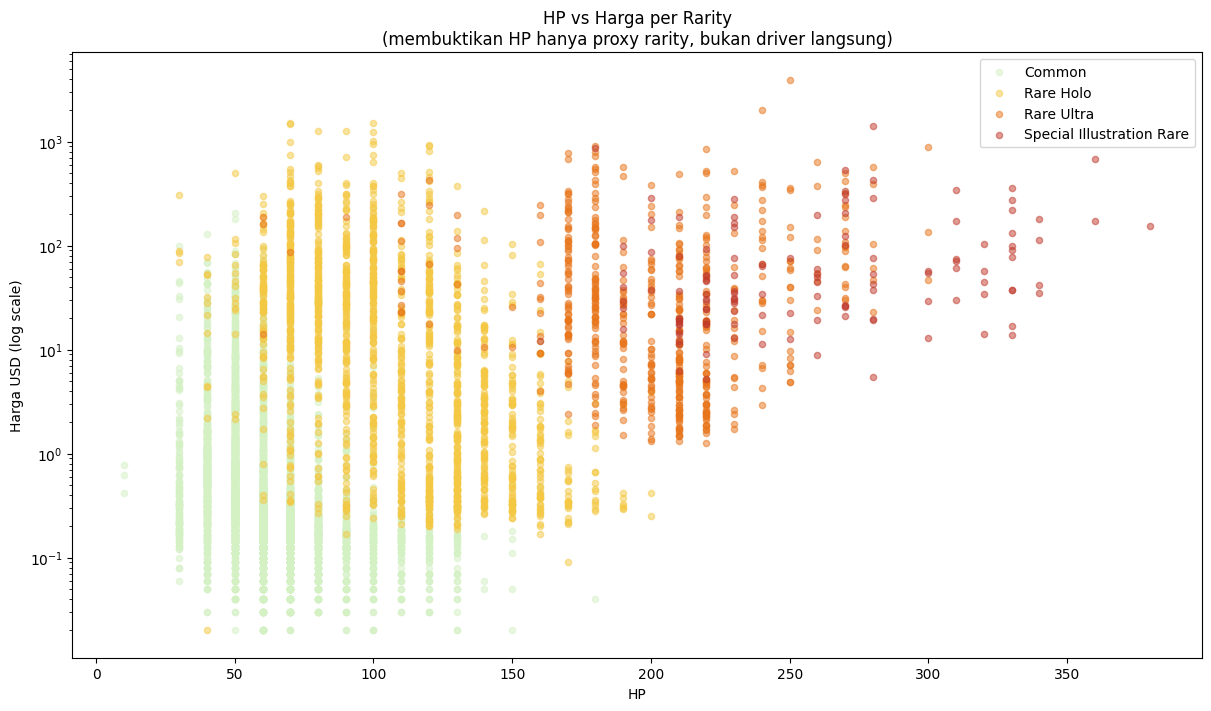

In [19]:
# Scatter plot: HP vs harga, diwarnai per rarity
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

rarity_sample = ["Common", "Rare Holo", "Rare Ultra", 
                 "Special Illustration Rare"]
palette = {"Common": "#d4f1c4", "Rare Holo": "#f4c842",
           "Rare Ultra": "#e8751a", "Special Illustration Rare": "#c0392b"}

for rarity, color in palette.items():
    subset = df[df["rarity"] == rarity].dropna(subset=["hp", "effective_market_price"])
    ax.scatter(subset["hp"], subset["effective_market_price"],
               label=rarity, color=color, alpha=0.5, s=20)

ax.set_yscale("log")
ax.set_title("HP vs Harga per Rarity\n(membuktikan HP hanya proxy rarity, bukan driver langsung)")
ax.set_xlabel("HP")
ax.set_ylabel("Harga USD (log scale)")
ax.legend()
plt.show()

## Drill Down -- Subtype

=== Median Harga per Subtype ===
                median_harga    geo_mean  jumlah_kartu
subtypes_clean                                        
Level-Up              99.990  103.589505            78
MEGA                  49.745   54.118461            92
VMAX                   8.380   11.934279           209
VSTAR                  6.945    9.640923            94
BREAK                  5.830    8.252324            35
Stage 2                4.160    7.893447          1666
Unknown                2.090    4.095558           173
Special                1.335    2.886066           200
Supporter              1.175    3.609537          1106
Basic                  0.830    3.782007          9640
Stage 1                0.740    3.242428          4933
Stadium                0.530    2.959577           250
Item                   0.300    2.091797           795
Pokémon Tool           0.300    1.848456           294


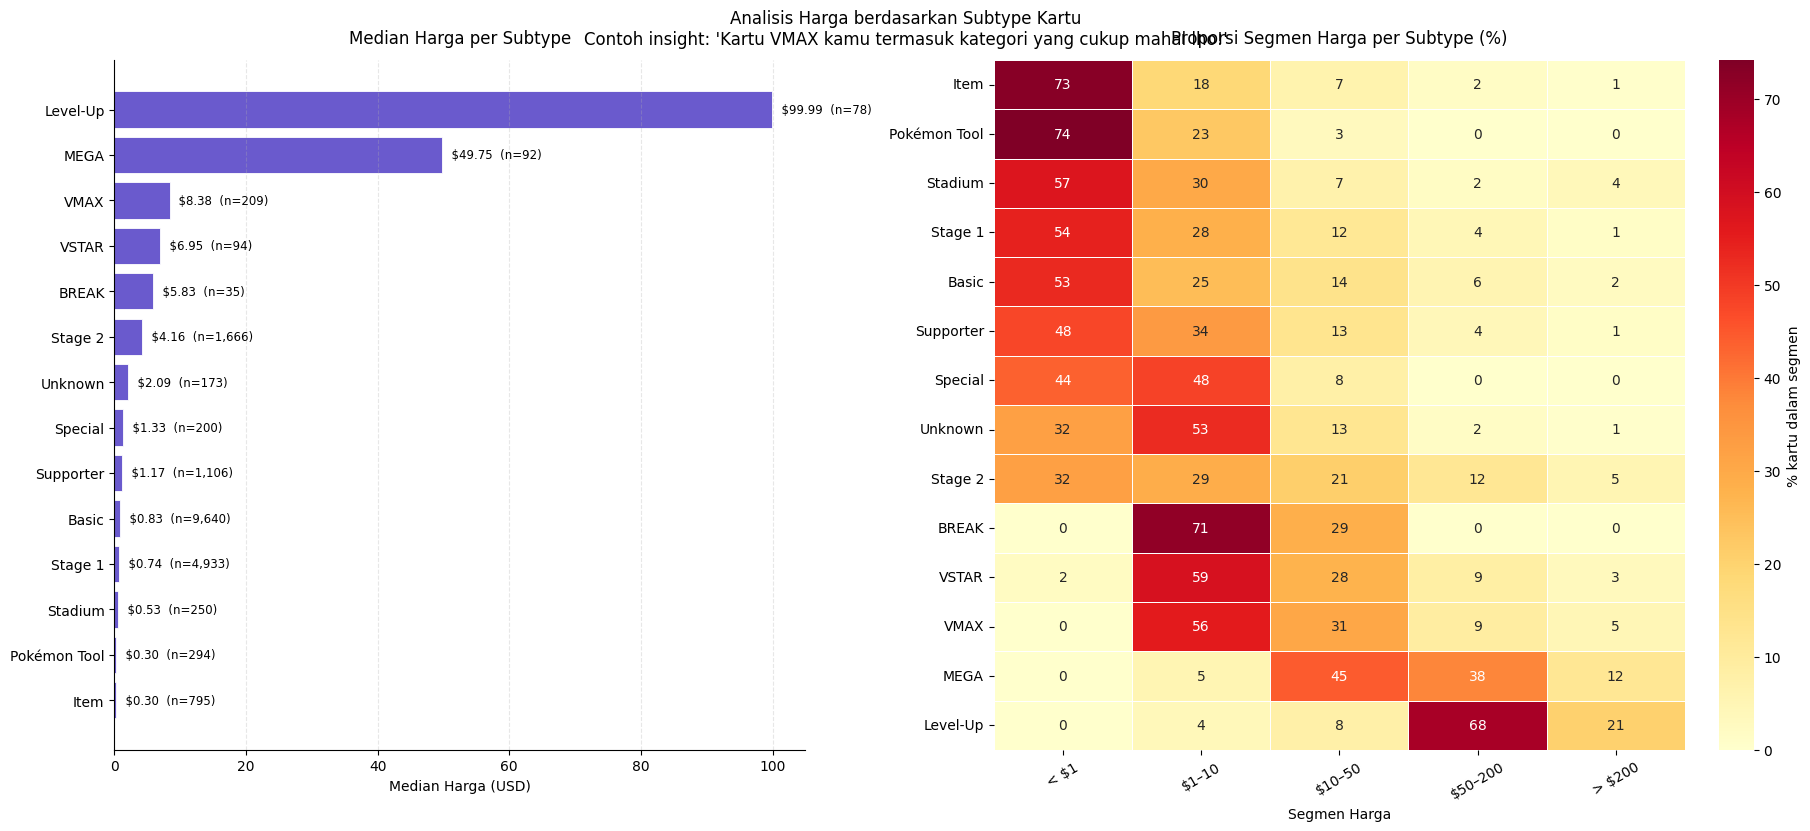

In [20]:
# ── Drill Down: Subtypes vs Harga ────────────────────────────────────

subtype_stats = (
    df.dropna(subset=["subtypes_clean", "effective_market_price"])
    .groupby("subtypes_clean")["effective_market_price"]
    .agg(
        median_harga="median",
        geo_mean=lambda x: np.exp(np.log1p(x).mean()),
        jumlah_kartu="count"
    )
    .query("jumlah_kartu >= 30")   # filter subtype yang cukup sampel
    .sort_values("median_harga", ascending=True)
)

print("=== Median Harga per Subtype ===")
print(subtype_stats.sort_values("median_harga", ascending=False).to_string())

# ── Visualisasi ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8), constrained_layout=True)

# Panel kiri: Bar chart median harga
bars = axes[0].barh(
    subtype_stats.index,
    subtype_stats["median_harga"],
    color="#6a5acd", edgecolor="white", linewidth=0.6
)
for bar, val, cnt in zip(bars, subtype_stats["median_harga"], subtype_stats["jumlah_kartu"]):
    axes[0].text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"  ${val:.2f}  (n={cnt:,})",
        va="center", fontsize=8.5
    )
axes[0].set_title("Median Harga per Subtype", pad=12)
axes[0].set_xlabel("Median Harga (USD)")
axes[0].grid(axis="x", linestyle="--", alpha=0.3)
axes[0].spines[["top", "right"]].set_visible(False)

# Panel kanan: Heatmap subtype × segmen harga
if "price_segment" not in df.columns:
    bins   = [0, 1, 10, 50, 200, float("inf")]
    labels = ["< $1", "$1–10", "$10–50", "$50–200", "> $200"]
    df["price_segment"] = pd.cut(df["effective_market_price"], bins=bins, labels=labels)

subtype_seg = (
    df.dropna(subset=["subtypes_clean", "price_segment"])
    .groupby(["subtypes_clean", "price_segment"], observed=True)
    .size()
    .unstack(fill_value=0)
    .apply(lambda x: x / x.sum() * 100, axis=1)
    .loc[subtype_stats.index]   # urutan sama dengan bar chart
)

sns.heatmap(
    subtype_seg,
    ax=axes[1],
    annot=True, fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.4,
    cbar_kws={"label": "% kartu dalam segmen"}
)
axes[1].set_title("Proporsi Segmen Harga per Subtype (%)", pad=12)
axes[1].set_xlabel("Segmen Harga")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=30)
axes[1].tick_params(axis="y", rotation=0)

fig.suptitle(
    "Analisis Harga berdasarkan Subtype Kartu\n"
    "Contoh insight: 'Kartu VMAX kamu termasuk kategori yang cukup mahal lho!'",
    fontsize=12, y=1.02
)
plt.show()

## Drill Down -- Type

=== Median Harga per Tipe Pokémon ===
             median_harga  geo_mean  jumlah_kartu
types_clean                                      
Dragon               2.51  6.303258           505
Lightning            1.87  5.050107          1463
Fairy                1.58  4.724333           233
Fire                 1.55  5.183775          1516
Psychic              1.17  4.493255          2253
Water                1.16  4.250810          2370
Colorless            1.10  4.114121          2109
Metal                0.88  3.636178           895
Darkness             0.79  4.144069          1183
Grass                0.76  3.233966          2327
Fighting             0.67  3.076848          1821


C:\Users\Tigro\AppData\Local\Temp\ipykernel_11992\627946343.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


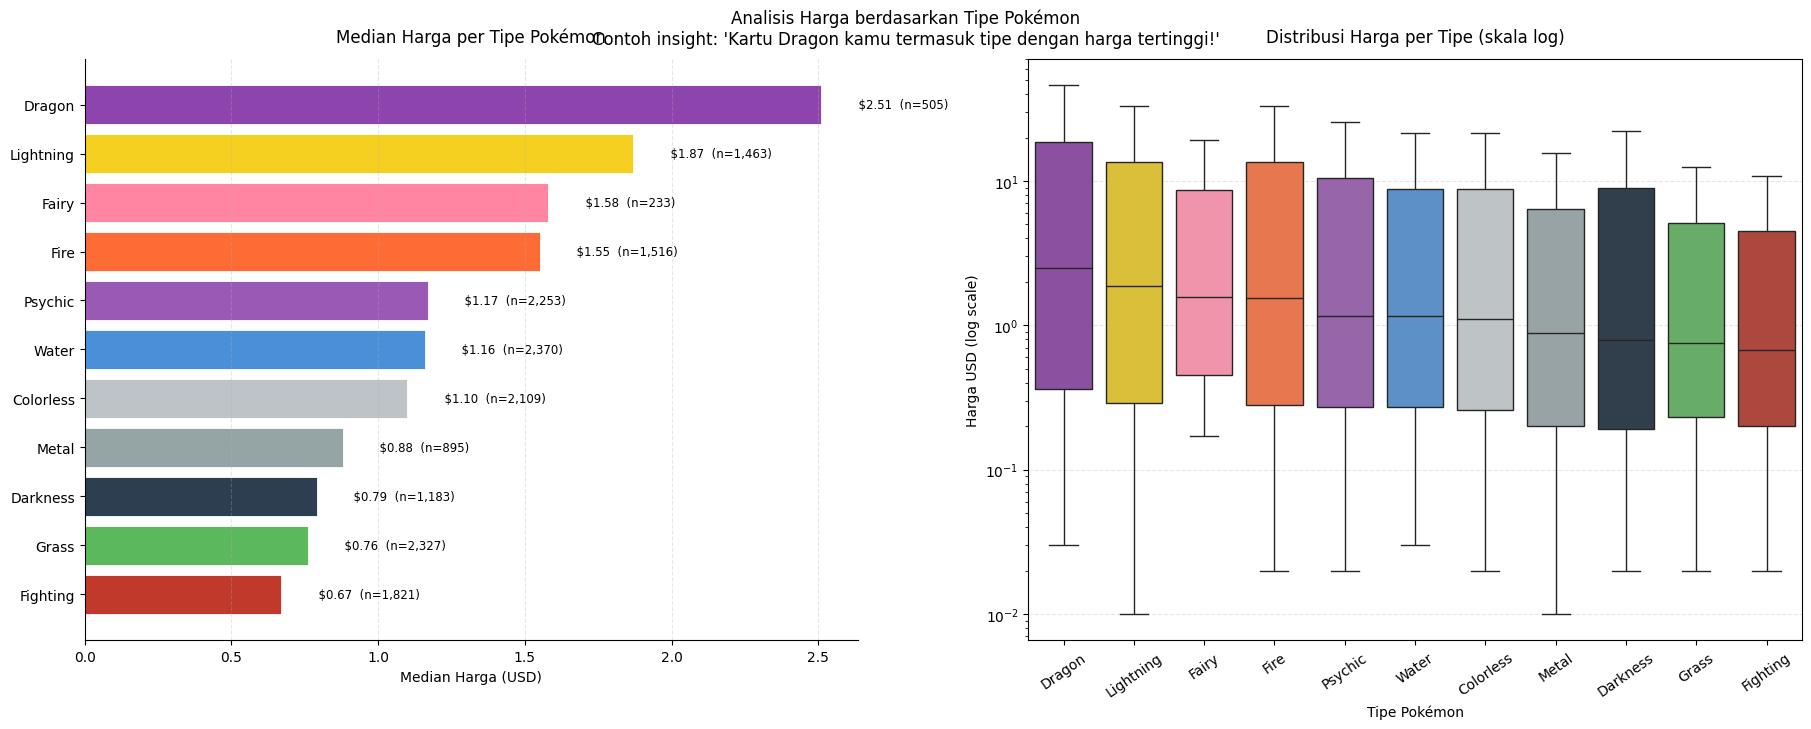

In [21]:
# ── Drill Down: Types vs Harga ────────────────────────────────────────

type_stats = (
    df.dropna(subset=["types_clean", "effective_market_price"])
    .query("types_clean != 'Unknown'")
    .groupby("types_clean")["effective_market_price"]
    .agg(
        median_harga="median",
        geo_mean=lambda x: np.exp(np.log1p(x).mean()),
        jumlah_kartu="count"
    )
    .sort_values("median_harga", ascending=True)
)

print("=== Median Harga per Tipe Pokémon ===")
print(type_stats.sort_values("median_harga", ascending=False).to_string())

# ── Visualisasi ──────────────────────────────────────────────────────
# Warna tiap tipe sesuai warna kartu aslinya
type_colors = {
    "Fire":       "#FF6B35",
    "Water":      "#4A90D9",
    "Grass":      "#5CB85C",
    "Lightning":  "#F5D020",
    "Psychic":    "#9B59B6",
    "Fighting":   "#C0392B",
    "Darkness":   "#2C3E50",
    "Metal":      "#95A5A6",
    "Dragon":     "#8E44AD",
    "Fairy":      "#FF85A2",
    "Colorless":  "#BDC3C7",
}
bar_colors = [type_colors.get(t, "#6a5acd") for t in type_stats.index]

fig, axes = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)

# Panel kiri: Bar chart dengan warna tipe
bars = axes[0].barh(
    type_stats.index,
    type_stats["median_harga"],
    color=bar_colors, edgecolor="white", linewidth=0.6
)
for bar, val, cnt in zip(bars, type_stats["median_harga"], type_stats["jumlah_kartu"]):
    axes[0].text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"  ${val:.2f}  (n={cnt:,})",
        va="center", fontsize=8.5
    )
axes[0].set_title("Median Harga per Tipe Pokémon", pad=12)
axes[0].set_xlabel("Median Harga (USD)")
axes[0].grid(axis="x", linestyle="--", alpha=0.3)
axes[0].spines[["top", "right"]].set_visible(False)

# Panel kanan: Box plot distribusi per tipe
order_types = type_stats.sort_values("median_harga", ascending=False).index.tolist()
sns.boxplot(
    data=df[df["types_clean"].isin(order_types)].dropna(subset=["effective_market_price"]),
    x="types_clean", y="effective_market_price",
    order=order_types,
    palette=type_colors,
    showfliers=False,
    ax=axes[1]
)
axes[1].set_yscale("log")
axes[1].set_title("Distribusi Harga per Tipe (skala log)", pad=12)
axes[1].set_xlabel("Tipe Pokémon")
axes[1].set_ylabel("Harga USD (log scale)")
axes[1].tick_params(axis="x", rotation=35)
axes[1].grid(axis="y", linestyle="--", alpha=0.3)

fig.suptitle(
    "Analisis Harga berdasarkan Tipe Pokémon\n"
    "Contoh insight: 'Kartu Dragon kamu termasuk tipe dengan harga tertinggi!'",
    fontsize=12, y=1.02
)
plt.show()

## Drill Down -- Set Name

=== Top 20 Set berdasarkan Median Harga ===
                        set.name             set.series  median_harga  jumlah_kartu
      Nintendo Black Star Promos                     NP        96.345            40
       Wizards Black Star Promos                   Base        44.710            53
          HGSS Black Star Promos HeartGold & SoulSilver        38.320            24
            DP Black Star Promos        Diamond & Pearl        34.430            51
                        Skyridge                 E-Card        31.815           182
            BW Black Star Promos          Black & White        21.190            99
            XY Black Star Promos                     XY        20.260           213
                       Aquapolis                 E-Card        19.690           181
             Expedition Base Set                 E-Card        14.480           165
   Crown Zenith Galarian Gallery         Sword & Shield        12.380            70
        Hidden Fates Shiny Vault

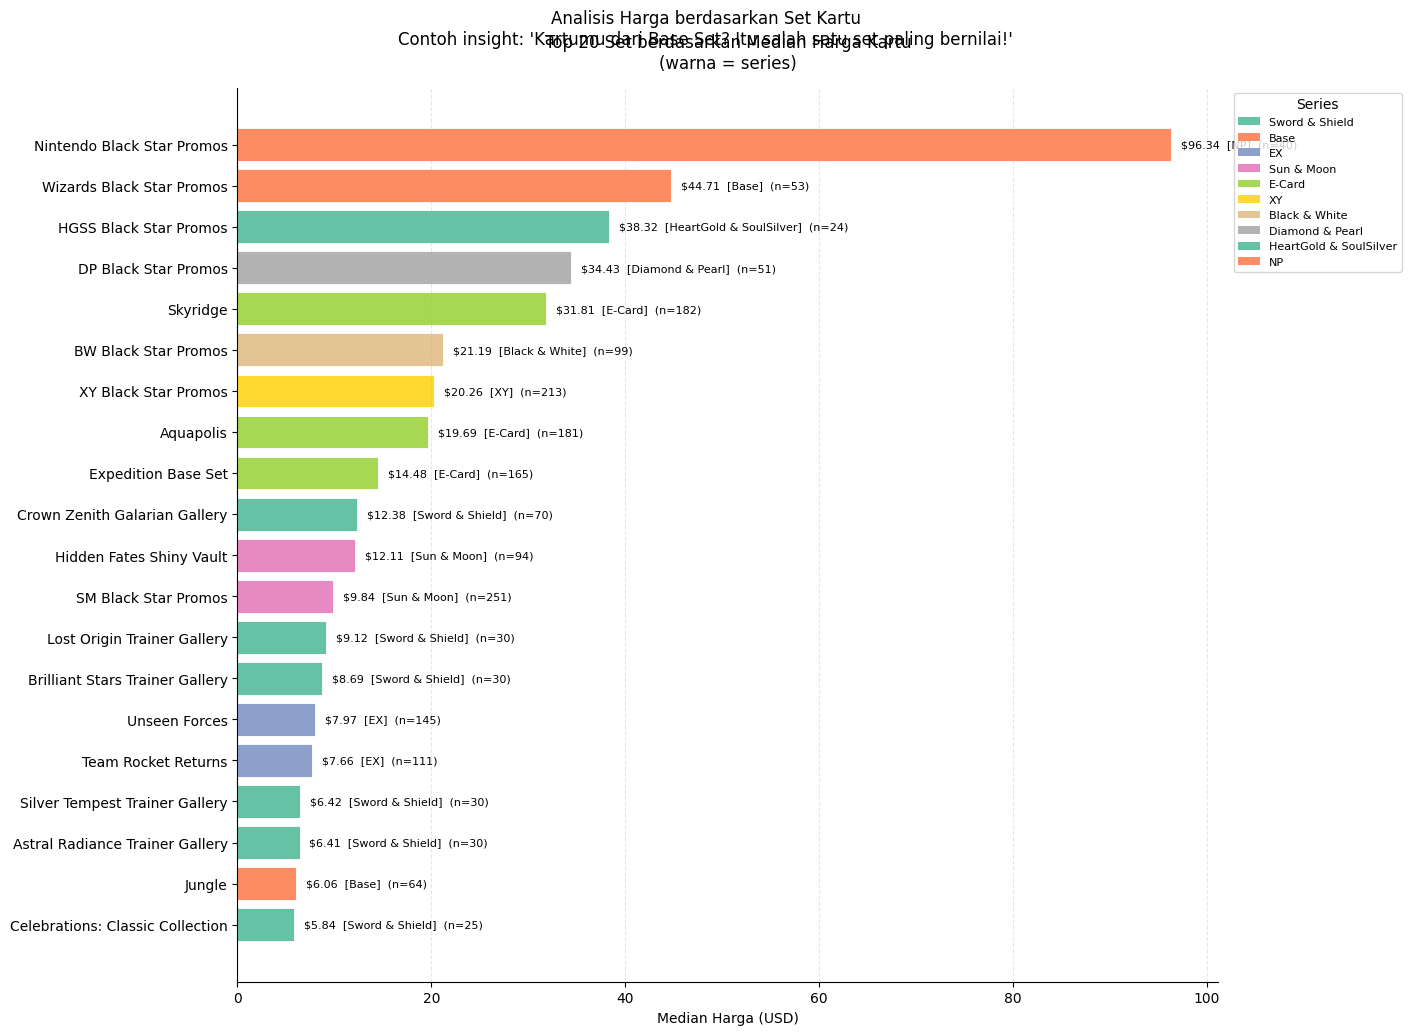

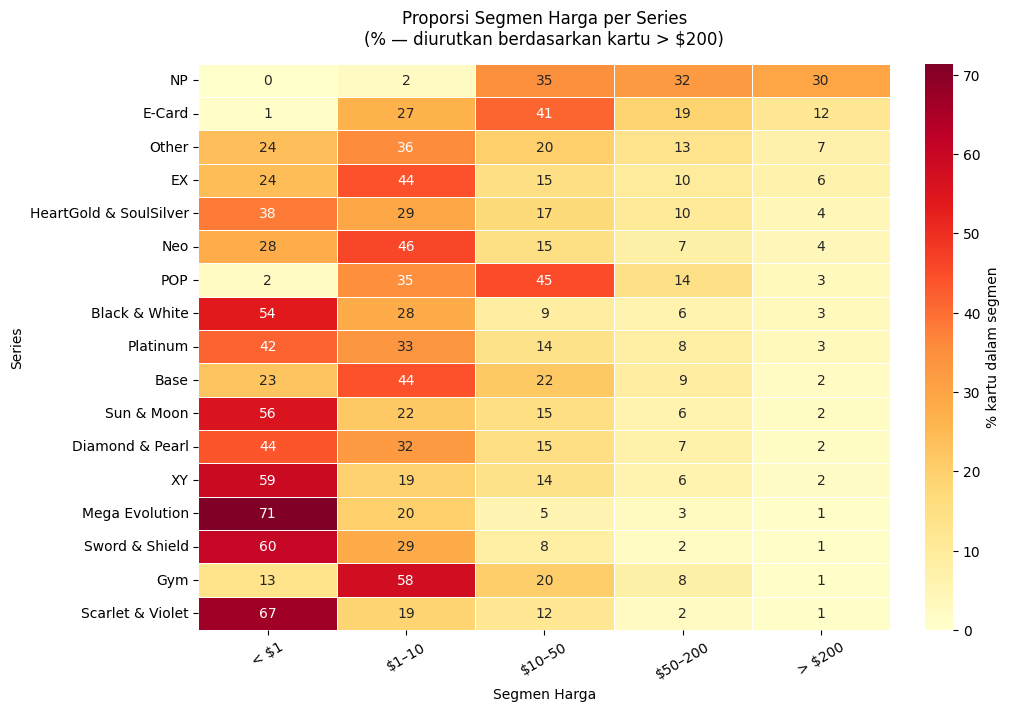

In [22]:
# ── Drill Down: Set Name vs Harga ────────────────────────────────────

set_stats = (
    df.dropna(subset=["set.name", "effective_market_price"])
    .groupby(["set.name", "set.series"])["effective_market_price"]
    .agg(
        median_harga="median",
        geo_mean=lambda x: np.exp(np.log1p(x).mean()),
        jumlah_kartu="count"
    )
    .reset_index()
    .query("jumlah_kartu >= 20")
    .sort_values("median_harga", ascending=False)
)

print("=== Top 20 Set berdasarkan Median Harga ===")
print(set_stats.head(20)[["set.name", "set.series", "median_harga", "jumlah_kartu"]].to_string(index=False))

# ── Visualisasi 1: Top 20 Set (bar chart) ────────────────────────────
top20_sets = set_stats.head(20).sort_values("median_harga", ascending=True)

# Warna per series
series_colors = {}
unique_series = top20_sets["set.series"].unique()
palette_series = plt.cm.Set2.colors
for i, s in enumerate(unique_series):
    series_colors[s] = palette_series[i % len(palette_series)]

bar_colors_set = [series_colors[s] for s in top20_sets["set.series"]]

fig, ax = plt.subplots(figsize=(14, 10), constrained_layout=True)

bars = ax.barh(
    top20_sets["set.name"],
    top20_sets["median_harga"],
    color=bar_colors_set, edgecolor="white", linewidth=0.6
)
for bar, val, cnt, series in zip(
    bars,
    top20_sets["median_harga"],
    top20_sets["jumlah_kartu"],
    top20_sets["set.series"]
):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"  ${val:.2f}  [{series}]  (n={cnt})",
        va="center", fontsize=8
    )

ax.set_title("Top 20 Set berdasarkan Median Harga Kartu\n(warna = series)", pad=14)
ax.set_xlabel("Median Harga (USD)")
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

# Legend series
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=s) for s, c in series_colors.items()]
ax.legend(handles=legend_elements, title="Series", 
          bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

fig.suptitle(
    "Analisis Harga berdasarkan Set Kartu\n"
    "Contoh insight: 'Kartumu dari Base Set? Itu salah satu set paling bernilai!'",
    fontsize=12, y=1.02
)
plt.show()

# ── Visualisasi 2: Heatmap Series × Segmen Harga ─────────────────────
series_seg = (
    df.dropna(subset=["set.series", "price_segment"])
    .groupby(["set.series", "price_segment"], observed=True)
    .size()
    .unstack(fill_value=0)
    .apply(lambda x: x / x.sum() * 100, axis=1)
    .sort_values("> $200", ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 7), constrained_layout=True)
sns.heatmap(
    series_seg,
    ax=ax,
    annot=True, fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "% kartu dalam segmen"}
)
ax.set_title("Proporsi Segmen Harga per Series\n(% — diurutkan berdasarkan kartu > $200)", pad=14)
ax.set_xlabel("Segmen Harga")
ax.set_ylabel("Series")
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)
plt.show()

## Drill Down -- Nama Pokemon

=== Top 20 Pokémon berdasarkan Median Harga ===
                   median_harga    geo_mean  max_harga  jumlah_kartu
pokemon_base_name                                                   
Primal                  276.590  182.513394     456.17             6
Rocket's                245.495  154.196413    2400.00            26
Shining                 185.835  126.543415    1111.59            20
Kyogre-EX               111.410   73.771830     316.48             5
Rayquaza                110.840  111.826930    2500.99            39
Umbreon                  96.830   91.430048    2283.14            37
Groudon-EX               81.730   74.053127     427.46             5
Charizard                77.575   75.749773    2999.99            66
Blastoise                75.655   54.381900     496.14            28
Sylveon-GX               71.770   61.610654     222.59             5
Mew                      68.935   66.273002    3500.00            44
Dragonite-GX             66.085   56.605004     142.38 

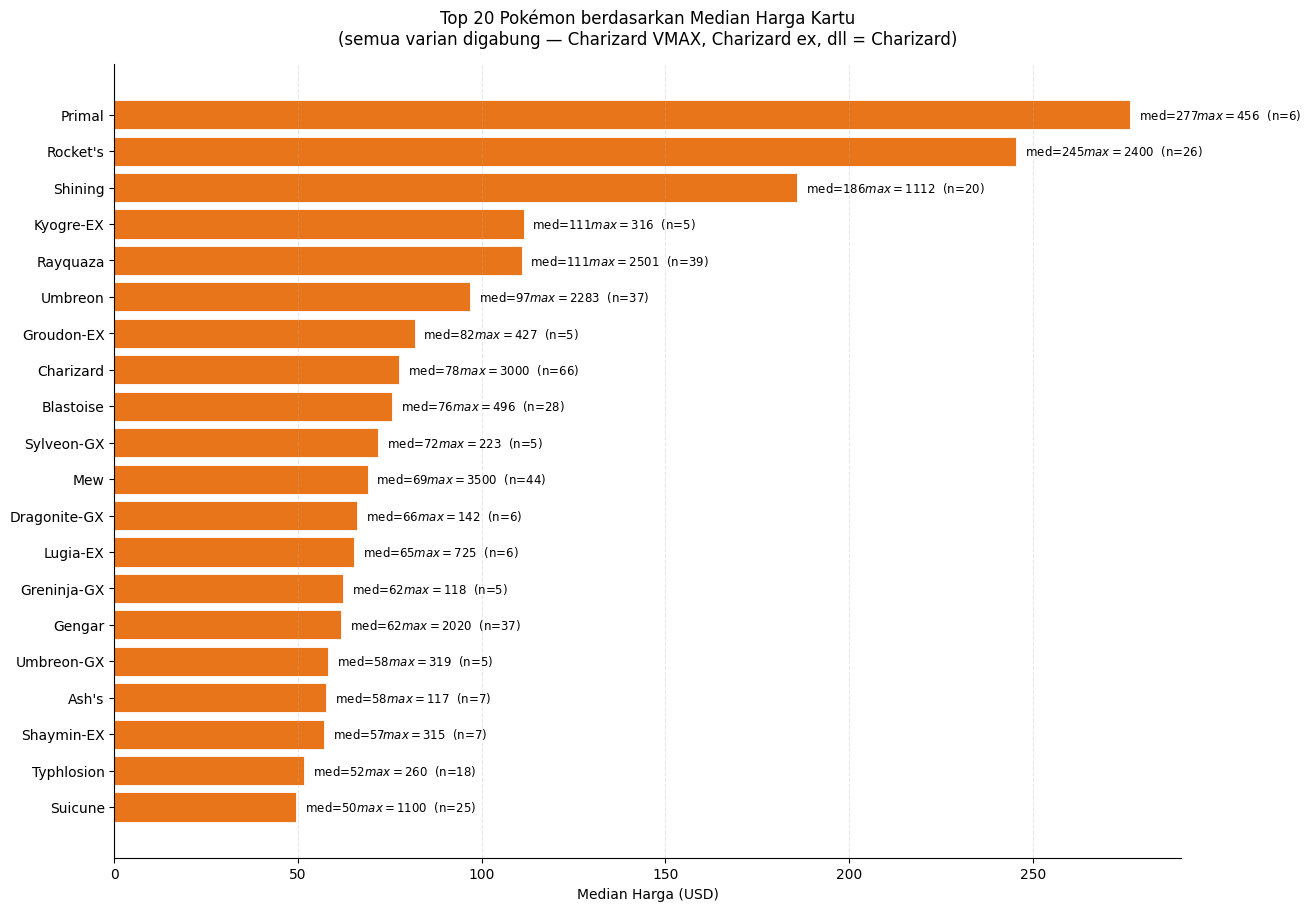

In [23]:
# ── Angle 1: Median harga per nama Pokémon ───────────────────────────

# Ekstrak nama dasar (kata pertama) untuk grup semua varian
# "Charizard VMAX", "Charizard V", "Dark Charizard" → semua jadi "Charizard"
df["pokemon_base_name"] = df["name"].apply(
    lambda x: str(x).split()[0] if pd.notna(x) else "Unknown"
)

pokemon_stats = (
    df.dropna(subset=["pokemon_base_name", "effective_market_price"])
    .query("supertype == 'Pokémon'")   # hanya kartu Pokémon, bukan Trainer/Energy
    .groupby("pokemon_base_name")["effective_market_price"]
    .agg(
        median_harga="median",
        geo_mean=lambda x: np.exp(np.log1p(x).mean()),
        max_harga="max",
        jumlah_kartu="count"
    )
    .query("jumlah_kartu >= 5")   # minimal 5 kartu agar tidak bias
    .sort_values("median_harga", ascending=False)
)

print("=== Top 20 Pokémon berdasarkan Median Harga ===")
print(pokemon_stats.head(20).to_string())

# ── Visualisasi: Top 20 Pokémon ──────────────────────────────────────
top20 = pokemon_stats.head(20).sort_values("median_harga", ascending=True)

fig, ax = plt.subplots(figsize=(13, 9), constrained_layout=True)

bars = ax.barh(
    top20.index,
    top20["median_harga"],
    color="#e8751a", edgecolor="white", linewidth=0.6
)
for bar, med, mx, cnt in zip(
    bars,
    top20["median_harga"],
    top20["max_harga"],
    top20["jumlah_kartu"]
):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"  med=${med:.0f}  max=${mx:.0f}  (n={cnt})",
        va="center", fontsize=8.5
    )

ax.set_title(
    "Top 20 Pokémon berdasarkan Median Harga Kartu\n"
    "(semua varian digabung — Charizard VMAX, Charizard ex, dll = Charizard)",
    pad=14
)
ax.set_xlabel("Median Harga (USD)")
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.show()